# Delivery Route Efficiency Analysis

A project to predict delivery times using the Food Delivery Dataset.

## Data Loading & Cleaning (Pandas)

In [2]:
import numpy as np
import pandas as pd

df=pd.read_csv('Food_Delivery_Route_Efficiency_Dataset.csv')

df['order_time'] = pd.to_datetime(df['order_time'])

df['hour'] = df['order_time'].dt.hour

df['day_of_week'] = df['order_time'].dt.dayofweek

print("new columns created")

print(df[['order_time','hour','day_of_week']].head())

new columns created
           order_time  hour  day_of_week
0 2025-01-01 15:29:00    15            2
1 2025-01-03 00:47:00     0            4
2 2025-01-04 17:32:00    17            5
3 2025-01-01 14:12:00    14            2
4 2025-01-02 16:50:00    16            3


## Feature Engineering (NumPy)

In [7]:
df['route_complexity'] = np.where(df['distance_km']>0 , df['route_length_km']/df['distance_km'] , 1)

df['avg_speed_kmh'] = df['distance_km'] / (df['delivery_time_min']/60)

print(df[['distance_km','route_length_km','route_complexity','avg_speed_kmh']].head())

   distance_km  route_length_km  route_complexity  avg_speed_kmh
0         7.97             9.75          1.223338       7.495298
1         0.90             1.28          1.422222       7.105263
2        11.12            16.65          1.497302       8.553846
3         4.90             5.25          1.071429      11.854839
4        10.04            11.34          1.129482      10.757143


## Exploratory Data Analysis (Visualization)

In [10]:
features = ['distance_km','traffic_level','route_length_km','delivery_mode','weather','hour','day_of_week']

x = df[features]
y = df['delivery_time_min'] # going to predict

x = pd.get_dummies(x,columns=['traffic_level','delivery_mode','weather'])

print(x.head())

   distance_km  route_length_km  hour  day_of_week  traffic_level_High  \
0         7.97             9.75    15            2                True   
1         0.90             1.28     0            4                True   
2        11.12            16.65    17            5               False   
3         4.90             5.25    14            2               False   
4        10.04            11.34    16            3                True   

   traffic_level_Low  traffic_level_Medium  delivery_mode_Bicycle  \
0              False                 False                   True   
1              False                 False                  False   
2              False                  True                  False   
3               True                 False                  False   
4              False                 False                  False   

   delivery_mode_Bike  delivery_mode_Car  delivery_mode_Scooter  \
0               False              False                  False   
1     

## Training the Machine Learning Model

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size= 0.2, random_state =42)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(x_train,y_train)

predictions = model.predict(x_test)

mae = mean_absolute_error(y_test, predictions)

rmse = np.sqrt(mean_squared_error(y_test, predictions))

print("mean absolute error",mae,"minutes")

print("mean squared error", rmse,"minutes")

mean absolute error 7.8946 minutes
mean squared error 10.051306226058387 minutes


## Feature Importance (which caused more delays)

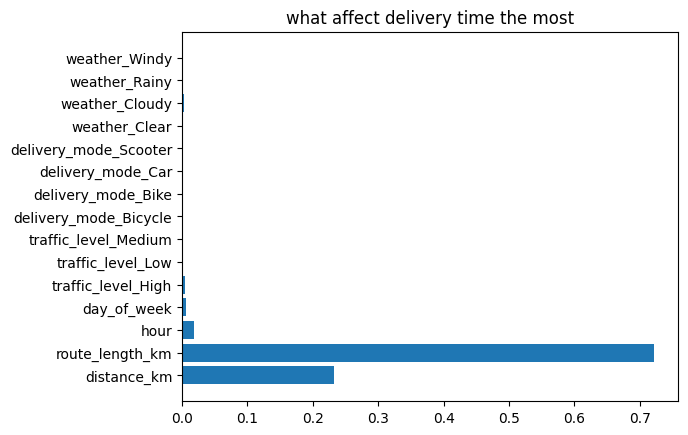

In [13]:
import matplotlib.pyplot as plt

importances = model.feature_importances_
feature_name = x.columns

plt.barh(feature_name,importances)

plt.title("what affect delivery time the most")
plt.show()
